In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Error detection with noise between operations

In [23]:
df_u = pd.read_csv("eight_qubit_unmitigated_result.csv")
df_m = pd.read_csv("eight_qubit_mitigated_result.csv")

Text(0.5, 0, '$p_d$')

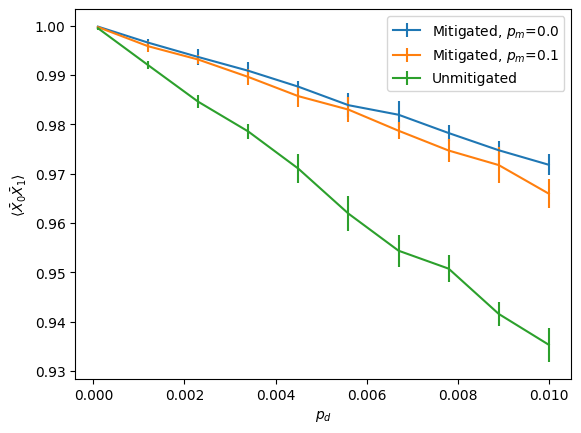

In [24]:
fig, ax = plt.subplots()
for meas_noise_rate in np.unique(df_m["meas_noise_rate"]):
    df_m_nr = df_m[df_m["meas_noise_rate"] == meas_noise_rate]
    ax.errorbar(df_m_nr["noise_rate"], df_m_nr["avg"], yerr=df_m_nr["std"], label=rf"Mitigated, $p_m$={meas_noise_rate}")
ax.errorbar(df_u["noise_rate"], df_u["avg"], yerr=df_u["std"], label="Unmitigated")
ax.legend()
ax.set_ylabel(r"$\langle \bar{X}_0\bar{X}_1 \rangle$")
ax.set_xlabel(r"$p_d$")

## Subspace expansion with circuit-level noise

In [25]:
df_u = pd.read_csv("eight_qubit_unmitigated_result2.csv")
df_m = pd.read_csv("eight_qubit_mitigated_result2.csv")

Text(0.5, 0, '$p_d$')

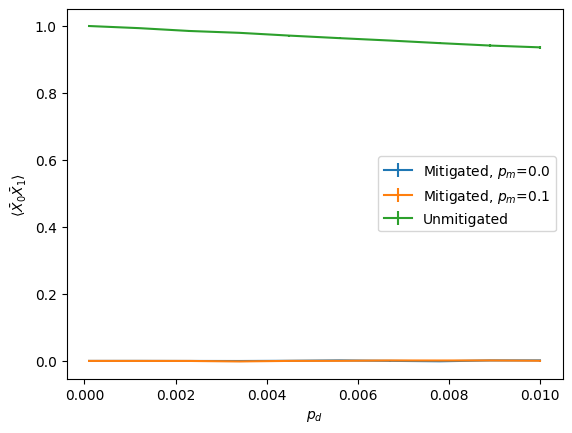

In [26]:
fig, ax = plt.subplots()
for meas_noise_rate in np.unique(df_m["meas_noise_rate"]):
    df_m_nr = df_m[df_m["meas_noise_rate"] == meas_noise_rate]
    ax.errorbar(df_m_nr["noise_rate"], df_m_nr["avg"], yerr=df_m_nr["std"], label=rf"Mitigated, $p_m$={meas_noise_rate}")
ax.errorbar(df_u["noise_rate"], df_u["avg"], yerr=df_u["std"], label="Unmitigated")
ax.legend()
ax.set_ylabel(r"$\langle \bar{X}_0\bar{X}_1 \rangle$")
ax.set_xlabel(r"$p_d$")

## Logical circuit

In [27]:
with open("eight_qubit_circuits.pkl", "rb") as f:
    input_dict= pickle.load(f)

encoding_ckt = input_dict["encoding"]
logical_h = input_dict["logical_h"]
logical_cx = input_dict["logical_cx"]
logical_ckt_stim = logical_h + logical_cx

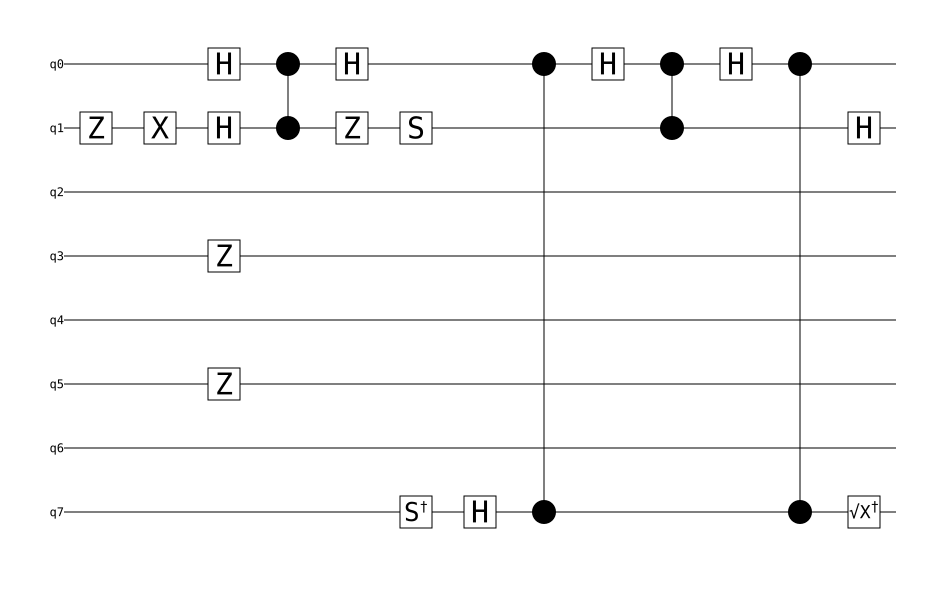

In [28]:
logical_h.diagram('timeline-svg')

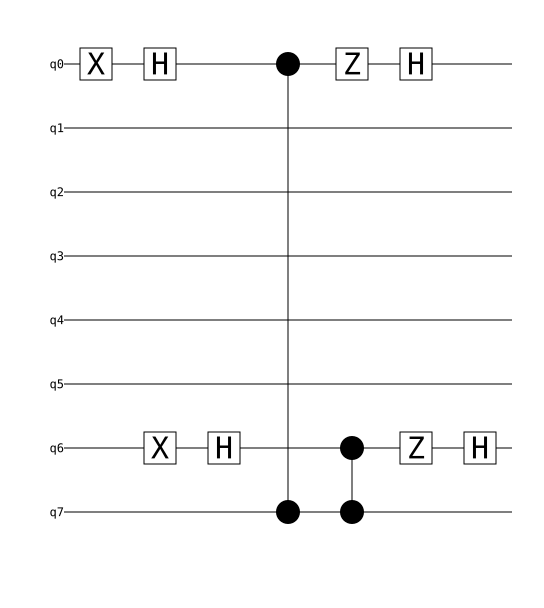

In [29]:
logical_cx.diagram('timeline-svg')

## Four-qubit system

In [30]:
df_u = pd.read_csv("four_qubit_unmitigated_result.csv")
df_m = pd.read_csv("four_qubit_mitigated_result.csv")

In [31]:
df_5q = pd.read_csv("five_qubit_mitigated_result.csv")

Text(0.5, 0, '$p_d$')

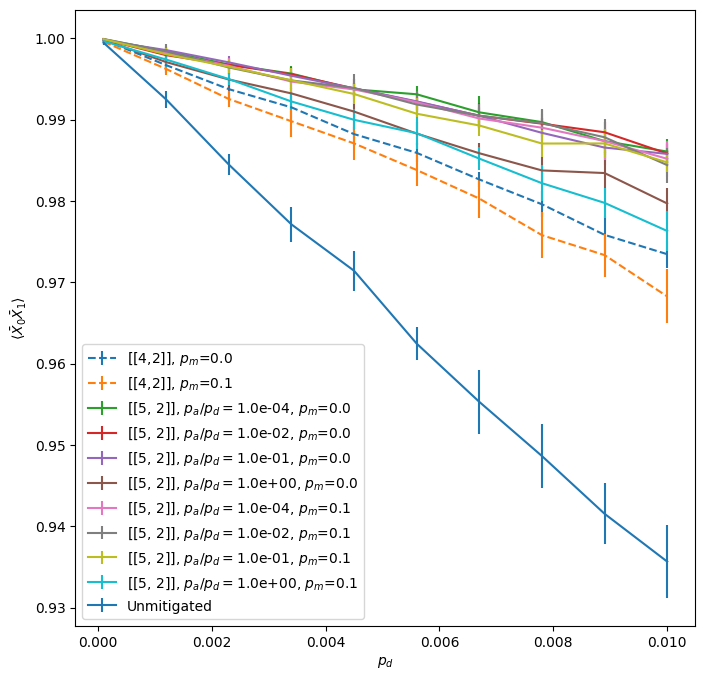

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
for meas_noise_rate in np.unique(df_m["meas_noise_rate"]):
    df_m_nr = df_m[df_m["meas_noise_rate"] == meas_noise_rate]
    ax.errorbar(df_m_nr["noise_rate"], df_m_nr["avg"], yerr=df_m_nr["std"], linestyle="--", label=rf"[[4,2]], $p_m$={meas_noise_rate}")
for meas_noise_rate in np.unique(df_5q["meas_noise_rate"]):
    df_5q_nr = df_5q[df_5q["meas_noise_rate"] == meas_noise_rate]
    for noise_ratio in np.unique(df_5q_nr["noise_ratio"]):
        df_5q_nr_r = df_5q_nr[df_5q_nr["noise_ratio"] == noise_ratio]
        ax.errorbar(
            df_5q_nr_r["noise_rate"], df_5q_nr_r["avg"], yerr=df_5q_nr_r["std"],
            label=rf"[[5, 2]], $p_a/p_d=${noise_ratio:2.1e}, $p_m$={meas_noise_rate}"
        )
ax.errorbar(df_u["noise_rate"], df_u["avg"], yerr=df_u["std"], label="Unmitigated")
ax.legend()
ax.set_ylabel(r"$\langle \bar{X}_0\bar{X}_1 \rangle$")
ax.set_xlabel(r"$p_d$")

## Circuit-level noise

In [44]:
df_u = pd.read_csv("four_qubit_unmitigated_ckt_level_result.csv")
df_m = pd.read_csv("four_qubit_mitigated_ckt_level_result.csv")

In [47]:
df_5q = pd.read_csv("five_qubit_mitigated_ckt_level_result.csv")

Text(0.5, 0, '$p_d$')

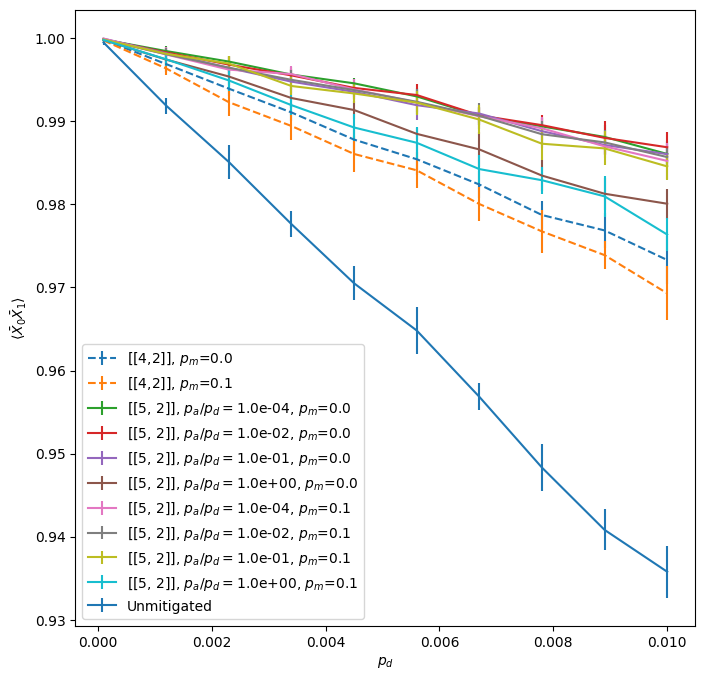

In [48]:
fig, ax = plt.subplots(figsize=(8, 8))
for meas_noise_rate in np.unique(df_m["meas_noise_rate"]):
    df_m_nr = df_m[df_m["meas_noise_rate"] == meas_noise_rate]
    ax.errorbar(df_m_nr["noise_rate"], df_m_nr["avg"], yerr=df_m_nr["std"], linestyle="--", label=rf"[[4,2]], $p_m$={meas_noise_rate}")
for meas_noise_rate in np.unique(df_5q["meas_noise_rate"]):
    df_5q_nr = df_5q[df_5q["meas_noise_rate"] == meas_noise_rate]
    for noise_ratio in np.unique(df_5q_nr["noise_ratio"]):
        df_5q_nr_r = df_5q_nr[df_5q_nr["noise_ratio"] == noise_ratio]
        ax.errorbar(
            df_5q_nr_r["noise_rate"], df_5q_nr_r["avg"], yerr=df_5q_nr_r["std"],
            label=rf"[[5, 2]], $p_a/p_d=${noise_ratio:2.1e}, $p_m$={meas_noise_rate}"
        )
ax.errorbar(df_u["noise_rate"], df_u["avg"], yerr=df_u["std"], label="Unmitigated")
ax.legend()
ax.set_ylabel(r"$\langle \bar{X}_0\bar{X}_1 \rangle$")
ax.set_xlabel(r"$p_d$")